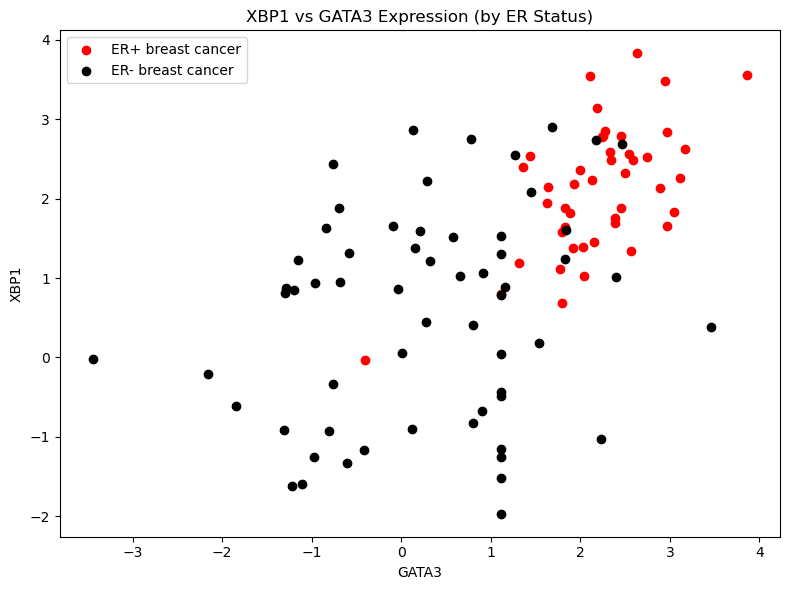

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df1 = pd.read_csv('filtered.tsv.gz', sep='\t', compression='gzip',low_memory=False)
df2 = pd.read_csv('class.tsv', sep='\t', header=None, low_memory=False)
columns = pd.read_csv('columns.tsv.gz', sep='\t', comment='#',compression='gzip',low_memory=False)
gata3_id = columns.loc[columns['GeneSymbol'] == 'GATA3', 'ID'].values[0]
xbp1_id = columns.loc[columns['GeneSymbol'] == 'XBP1', 'ID'].values[0]
gata3_exp = df1[f" {gata3_id}"]
xbp1_exp = df1[f" {xbp1_id}"]
labels = df2.iloc[:, 0]

plt.figure(figsize=(8, 6))
plt.scatter(gata3_exp[labels == 1], xbp1_exp[labels == 1], color='red', alpha=1.0, label='ER+ breast cancer')
plt.scatter(gata3_exp[labels == 0], xbp1_exp[labels == 0], color='black', alpha=1.0, label='ER- breast cancer')
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('XBP1 vs GATA3 Expression (by ER Status)')
plt.legend()
plt.tight_layout()
plt.show()

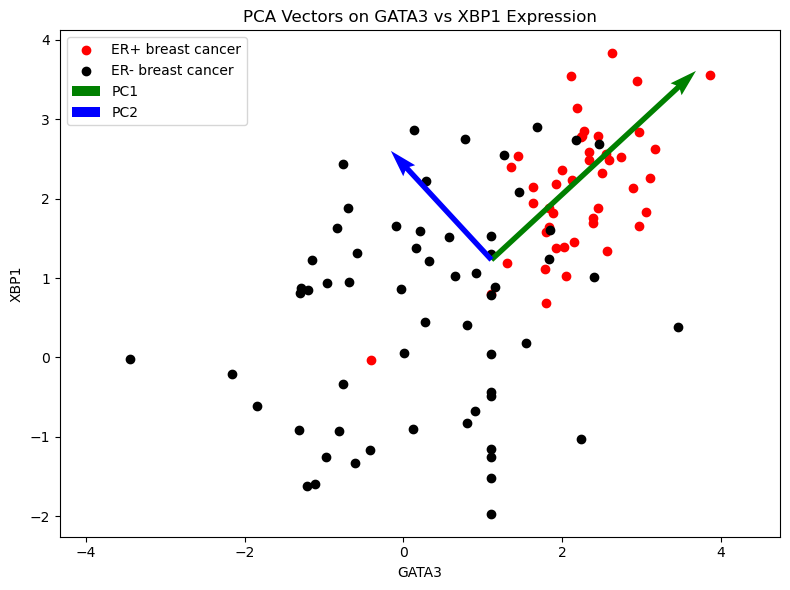

In [15]:
points = np.column_stack((gata3_exp, xbp1_exp))
mean = points.mean(axis=0)
centr = points - mean
cov = np.cov(centr.T)
eig_vals, eig_vecs = np.linalg.eig(cov)
sorted_ind = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_ind]
eig_vecs = eig_vecs[:, sorted_ind]

plt.figure(figsize=(8, 6))
plt.scatter(gata3_exp[labels == 1], xbp1_exp[labels == 1], color='red', alpha=1.0, label='ER+ breast cancer')
plt.scatter(gata3_exp[labels == 0], xbp1_exp[labels == 0], color='black', alpha=1.0, label='ER- breast cancer')
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('PCA Vectors on GATA3 vs XBP1 Expression')

for i in range(2):
    direction = eig_vecs[:, i]
    magnitude = np.sqrt(eig_vals[i]) * 2  
    plt.quiver(*mean, *(direction * magnitude),angles='xy', scale_units='xy', scale=1,
               color='green' if i == 0 else 'blue',label=f'PC{i+1}')

plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

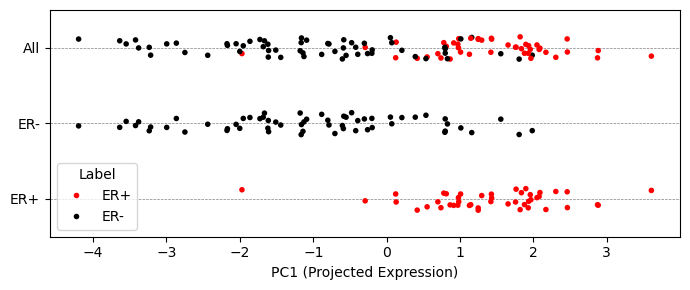

In [16]:
pc1_scores = centr @ eig_vecs[:, 0]
labels_named = labels.map({0: 'ER-', 1: 'ER+'})

pc1_df = pd.DataFrame({'PC1': pc1_scores,'Label': labels_named})

grp = pc1_df.copy()
grp['Group'] = 'All'

grp_neg = pc1_df[pc1_df['Label'] == 'ER-'].copy()
grp_neg['Group'] = 'ER-'

grp_pos = pc1_df[pc1_df['Label'] == 'ER+'].copy()
grp_pos['Group'] = 'ER+'

combined_df = pd.concat([grp, grp_neg, grp_pos], ignore_index=True)

plt.figure(figsize=(7, 3))
ax = sns.stripplot(data=combined_df,x='PC1',y='Group',hue='Label',palette={'ER-': 'black', 'ER+': 'red'},
    dodge=False,jitter=0.15,size=4,alpha=1.0,orient='h')

for i, group in enumerate(['All', 'ER-', 'ER+']):
    ax.axhline(y=i, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel('PC1 (Projected Expression)')
plt.ylabel('')
plt.tight_layout()
plt.show()